In [4]:
import pandas as pd
df_scores = pd.DataFrame({
    "student":  ["Anna","Ben", "Chris", "Diana", "Eva"],
    "score":  [95, 78, 61, 43, 88]
})
df_scores

,student,score
0,Anna,95
1,Ben,78
2,Chris,61
3,Diana,43
4,Eva,88


In [6]:
def score_label (score):
    if score >= 90:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 50:
        return "Pass"
    else:
        return "Fail"
score_label(86)

'Good'

### option 1


In [7]:
df_scores["score_label"] = df_scores["score"].apply(score_label)

In [8]:
df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


### option 2

In [10]:
df_scores["score_label"] = [score_label(i) for i in df_scores["score"]]
df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


In [ ]:
def classify_price(price, low = 5, high = 15):
    if price <= low:
        return "Low-range product"
    elif price <= high:
        return "Mid-range product"
    else:
        return "High-range product"
classify_price(9)

'Mid-range product'

In [12]:
classify_price(9, low = 3, high = 10)

'Mid-range product'

In [13]:
df_products_dummy = pd.DataFrame({
    "product":["Milk", "Bread", "Juice", "Cheese", "Steak", "Apples"],
    "price":[2.5, 1.8, 6.2, 12.0, 24.5, 4.2]
})
df_products_dummy

,product,price
0,Milk,2.5
1,Bread,1.8
2,Juice,6.2
3,Cheese,12.0
4,Steak,24.5
5,Apples,4.2


In [15]:
df_products_dummy["classify_range"] = df_products_dummy["price"].apply(classify_price)
df_products_dummy

,product,price,classify_range
0,Milk,2.5,Low-range product
1,Bread,1.8,Low-range product
2,Juice,6.2,Mid-range product
3,Cheese,12.0,Mid-range product
4,Steak,24.5,High-range product
5,Apples,4.2,Low-range product


### Task 1
Create a function called age_group_label() that groups ages into:

Young for age below 30
Middle for age from 30 to 59
Senior for age 60 and above

In [ ]:
def age_group_label(age):
    if age <= 0:
        return
    if age >= 60:
        return "Senior"
    elif 30<= age <= 59:
        return "Middle"
    else:
        return "Young"
age_group_label()

'Young'

### Task 2
Create a function called income_band() that groups income into:

Low income
Middle income
High income
using thresholds of your choice.

In [ ]:
def income_band(income):
    if income <= 0:
        return
    if income >= 70000:
        return 'High Income'
    elif income >= 40000:
        return 'Middle Income'
    else:
        return 'Low Income'
income_band()

'Middle Income'

### Task 3
Task 3
Apply both functions to the synthetic DataFrame below.

df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age": [22, 35, 47, 63, 29],
    "income": [18000, 42000, 72000, 95000, 25000]
})

df_customers_dummy

In [26]:
df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age":[22, 35, 47, 63, 29],
    "income":[18000, 42000, 72000, 95000, 25000]
})
df_customers_dummy

,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


In [28]:
df_customers_dummy["customer_age_label"]  = df_customers_dummy["age"].apply(age_group_label)
df_customers_dummy["income_band_label"] = df_customers_dummy["income"].apply(income_band)
df_customers_dummy

,customer,age,income,customer_age_label,income_band_label
0,A,22,18000,Young,Low Income
1,B,35,42000,Middle,Middle Income
2,C,47,72000,Middle,High Income
3,D,63,95000,Senior,High Income
4,E,29,25000,Young,Low Income


In [61]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt

In [31]:
df_instacart = pd.read_parquet("../data/processed/instacart.parquet")

In [32]:
def price_label(row):
    if row['prices'] <= 5:
        return 'Low-range product'
    elif row['prices'] <= 15:
        return 'Mid_range product'
    elif row['prices'] > 15:
        return 'High-range product'
    else:
        return 'Not enough data'

In [38]:
#defualt sksenq 
df_instacart['price_range'] = 'Not enough data'

df_instacart.loc[df_instacart['prices'] > 7, 'price_range'] = 'High-range product'
df_instacart.loc[(df_instacart['prices'] <= 7 ) & (df_instacart['prices'] > 2), 'price_range'] = 'Mid-range product'
df_instacart.loc[df_instacart['prices'] <= 2, 'price_range'] = 'Low-range product'
df_instacart.head()


,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,aisle,First Name,Surnam,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division,price_range
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,soft drinks,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,High-range product
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,packaged cheese,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,High-range product
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,yogurt,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,High-range product
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,paper goods,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,Low-range product
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,candy chocolate,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,Mid-range product


In [ ]:
df_instacart['price_range'] = df_instacart.apply(price_label, axis = 1)
df_instacart['price_range'].value_counts(dropna = False)


price_range
Mid_range product     936243
Low-range product     430870
High-range product     17505
Not enough data           88
Name: count, dtype: int64

In [51]:
age_T = pd.DataFrame(df_instacart['Age'].unique()).iloc[:10].T
age_T

,0,1,2,3,4,5,6,7,8,9
0,31,68,75,39,32,79,34,51,66,58


In [52]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"

df_instacart["age_group"] = df_instacart["Age"].apply(age_group)
df_instacart["age_group"].value_counts(dropna=False)

age_group
Middle    652827
Senior    470466
Young     261413
Name: count, dtype: int64

In [53]:
def income_group(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"

df_instacart["income_group"] = df_instacart["income"].apply(income_group)
df_instacart["income_group"].value_counts(dropna=False)

income_group
High income      975334
Middle income    398848
Low income        10524
Name: count, dtype: int64

In [54]:
def order_time_band(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df_instacart["order_time_band"] = df_instacart["order_hour_of_day"].apply(order_time_band)
df_instacart["order_time_band"].value_counts(dropna=False)

order_time_band
Afternoon    669307
Morning      434015
Evening      254731
Night         26653
Name: count, dtype: int64

### lambda functions

In [55]:
df_scores["pass_flag"] = df_scores["score"].apply(lambda x: "Pass" if x >= 50 else "Fail")
df_scores

,student,score,score_label,pass_flag
0,Anna,95,Excellent,Pass
1,Ben,78,Good,Pass
2,Chris,61,Pass,Pass
3,Diana,43,Fail,Fail
4,Eva,88,Good,Pass


In [56]:
df_instacart["expensive_product"] = df_instacart["prices"].apply(
    lambda x: "Expensive" if x > 15 else "Not expensive"
)
df_instacart["expensive_product"].value_counts()

expensive_product
Not expensive    1367201
Expensive          17505
Name: count, dtype: int64

### VISUALIZATION

In [ ]:
price_range_counts = df_instacart['price_range'].value_counts().sort_values()
price_range_counts

price_range
Not enough data           88
Low-range product     125149
Mid-range product     528633
High-range product    730836
Name: count, dtype: int64

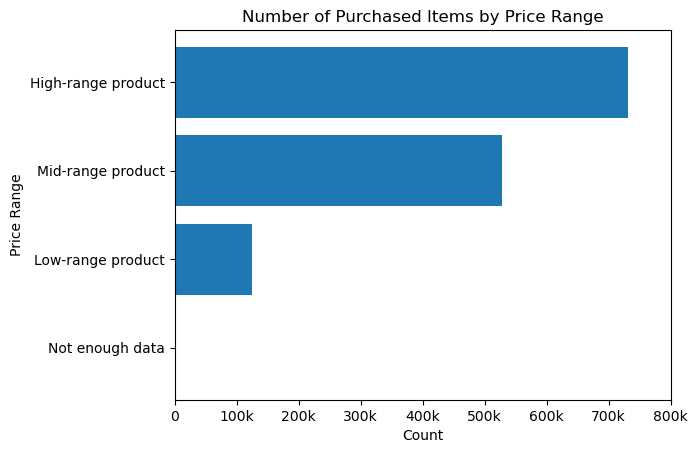

In [63]:
plt.figure()
plt.barh(price_range_counts.index, price_range_counts.values)
plt.title("Number of Purchased Items by Price Range")
plt.xlabel('Count')
plt.ylabel('Price Range')
ticks = [0, 100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000]
labels = ['0', '100k', '200k', '300k', '400k', '500k', '600k', '700k', '800k']
plt.xticks(ticks, labels)
plt.show()

In [67]:
reorder_by_price_range = (
    df_instacart
    .groupby("price_range")["reordered"]
    .mean()
    .sort_values(ascending=True)
)

reorder_by_price_range

price_range
Mid-range product     0.584536
High-range product    0.606968
Low-range product     0.609050
Not enough data       0.670455
Name: reordered, dtype: float64

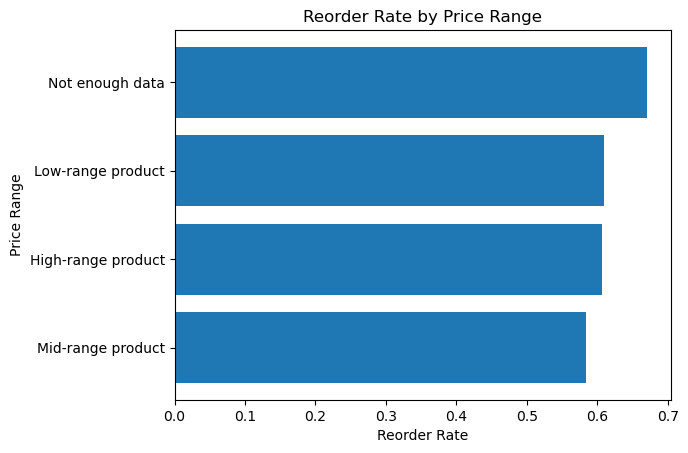

In [68]:
plt.figure()
plt.barh(reorder_by_price_range.index, reorder_by_price_range.values)
plt.title("Reorder Rate by Price Range")
plt.xlabel("Reorder Rate")
plt.ylabel("Price Range")
plt.show()

In [73]:
df_customers_unique = df_instacart[
    ["First Name", "Surname", "Age", "income", "age_group", "income_group", "region"]
].drop_duplicates()

df_customers_unique.head()

,First Name,Surname,Age,income,age_group,income_group,region
0,Linda,Nguyen,31,40423,Middle,Middle income,South
11,Norma,Chapman,68,64940,Senior,Middle income,West
42,Janet,Lester,75,115242,Senior,High income,West
51,Peter,Villegas,39,89095,Middle,High income,Northeast
60,Anna,Allison,32,88603,Middle,High income,South


In [ ]:
df_instacart.columns
df_instacart = df_instacart.rename(columns={
    'Surnam': 'Surname'
})

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name', 'Surnam',
       'Gender', 'state', 'Age', 'date_joined', 'n_dependants', 'fam_status',
       'income', 'region', 'division', 'price_range', 'age_group',
       'income_group', 'order_time_band', 'expensive_product'],
      dtype='str')


In [74]:
age_group_counts = df_customers_unique["age_group"].value_counts().sort_values()
age_group_counts

age_group
Young     24682
Senior    44829
Middle    61698
Name: count, dtype: int64

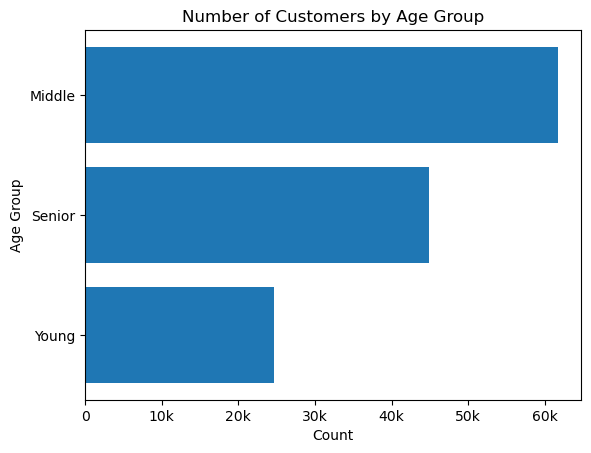

In [76]:
plt.figure()
plt.barh(age_group_counts.index, age_group_counts.values)
plt.title("Number of Customers by Age Group")
plt.xlabel("Count")
plt.ylabel("Age Group")
ticks = [0, 10000, 20000, 30000, 40000, 50000, 60000]
labels = ['0', '10k', '20k', '30k', '40k', '50k', '60k']
plt.xticks(ticks, labels)
plt.show()

In [77]:
avg_income_by_age_group = (
    df_customers_unique
    .groupby("age_group")["income"]
    .mean()
    .sort_values()
)

avg_income_by_age_group

age_group
Young      67597.200065
Middle     94492.928247
Senior    109688.877356
Name: income, dtype: float64

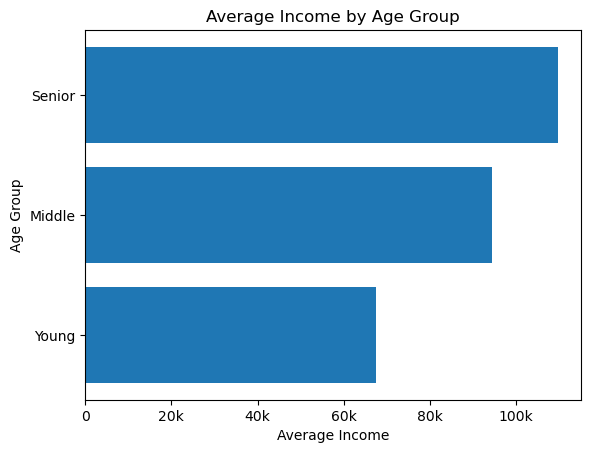

In [78]:
plt.figure()
plt.barh(avg_income_by_age_group.index, avg_income_by_age_group.values)
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.ylabel("Age Group")
ticks = [0, 20000, 40000, 60000, 80000, 100000]
labels = ['0', '20k', '40k', '60k', '80k', '100k']
plt.xticks(ticks, labels)
plt.show()

In [79]:
orders_time_band = (
    df_instacart[["order_id", "order_time_band"]]
    .drop_duplicates()
    .groupby("order_time_band")
    .size()
    .sort_values()
)

orders_time_band

order_time_band
Night         2507
Evening      24275
Morning      41068
Afternoon    63359
dtype: int64

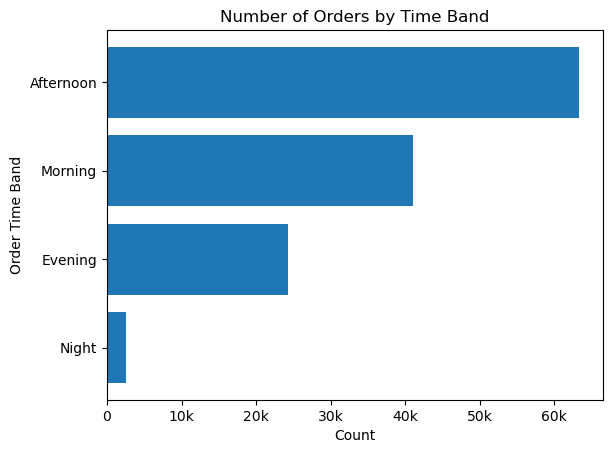

In [80]:
plt.figure()
plt.barh(orders_time_band.index, orders_time_band.values)
plt.title("Number of Orders by Time Band")
plt.xlabel("Count")
plt.ylabel("Order Time Band")
ticks = [0, 10000, 20000, 30000, 40000, 50000, 60000]
labels = ['0', '10k', '20k', '30k', '40k', '50k', '60k']
plt.xticks(ticks, labels)
plt.show()

### Practice Tasks

Task 1
Create a derived column called family_size_group based on n_dependants.
Suggested grouping:
No dependants
Small family
Large family

Task 2
Create a derived column called senior_flag based on Age.
Suggested logic:
Senior if age is 60 or more
Not senior otherwise

Task 3
Visualize the number of customers by income_group.

Task 4
Visualize the reorder rate by order_time_band.

Task 5
Create a flag variable on dow using both lambda and isin() methods:
weekend: True/1
weekday: False/1

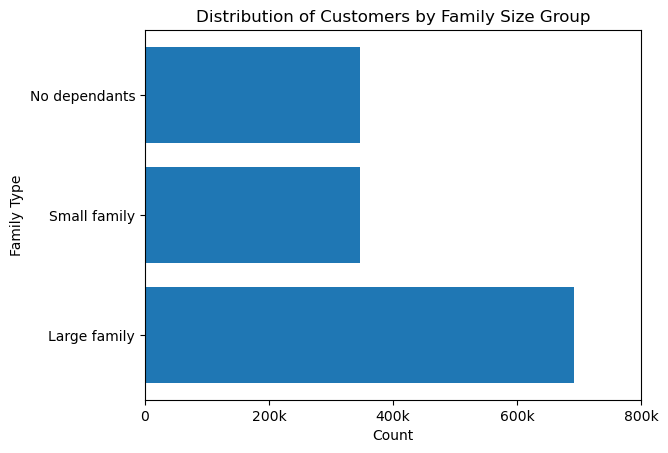

In [109]:
# TASK 1
def family_size_group(n):

    if n >= 2:
        return 'Large family'
    elif n >= 1:
        return 'Small family'
    elif n == 0:
        return 'No dependants'
    else:
        return

family_size_group(4)

df_instacart['family_size_group'] = df_instacart['n_dependants'].apply(family_size_group)
family_counts = df_instacart['family_size_group'].value_counts(dropna= False)

plt.figure()
plt.barh(family_counts.index, family_counts.values)
plt.title("Distribution of Customers by Family Size Group")
plt.xlabel('Count')
plt.ylabel('Family Type')
plt.xticks([0, 200000, 400000, 600000, 800000], ['0', '200k', '400k', '600k', '800k'])
plt.show()

In [103]:
df_instacart['family_size_group'].unique()

<ArrowStringArray>
['Large family', 'No dependants', 'Small family']
Length: 3, dtype: str

In [108]:
# TASK 2
def senior_flag(age):
    if age >= 60:
        return 'Senior'
    return 'Not Senior'
senior_flag(40)

df_instacart['senior_flag'] = df_instacart['Age'].apply(senior_flag)
senior_label = df_instacart['senior_flag'].value_counts(dropna= False)

senior_label


senior_flag
Not Senior    914240
Senior        470466
Name: count, dtype: int64

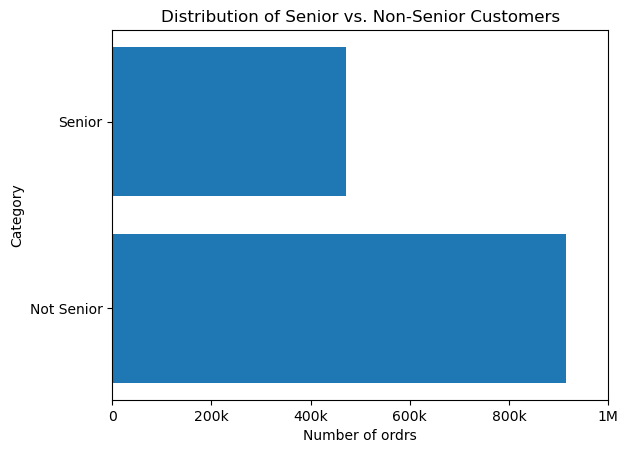

In [113]:
plt.figure()
plt.title('Distribution of Senior vs. Non-Senior Customers')
plt.barh(senior_label.index, senior_label.values)
plt.ylabel('Category')
plt.xlabel('Number of ordrs')
plt.xticks([0, 200000, 400000, 600000, 800000, 1000000], [0, '200k', '400k', '600k', '800k', '1M'])
plt.show()

In [121]:
# TASK 3
df_instacart.columns
df_instacart[['First Name', 'income_group']].drop_duplicates()
df_instacart.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division', 'price_range',
       'age_group', 'income_group', 'order_time_band', 'expensive_product',
       'family_size_group', 'senior_flag'],
      dtype='str')

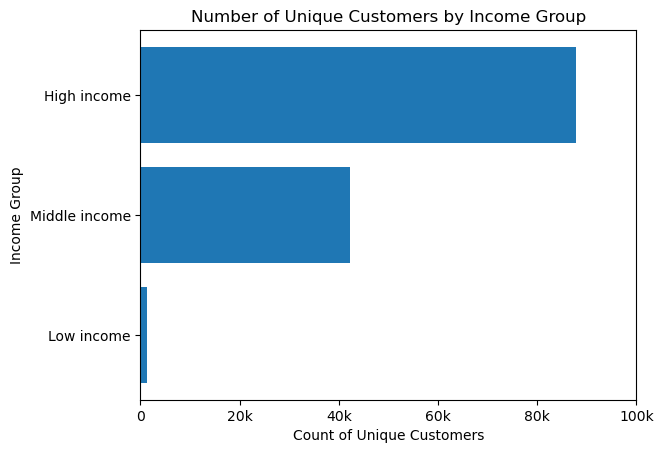

In [ ]:
income_counts = df_customers_unique['income_group'].value_counts().sort_values()
plt.figure()
plt.barh(income_counts.index, income_counts.values)
plt.title("Number of Unique Customers by Income Group")
plt.xlabel("Count of Unique Customers")
plt.ylabel("Income Group")
plt.xticks([0, 20000, 40000, 60000, 80000, 100000], [0, '20k', '40k', '60k', '80k', '100k'])
plt.show()

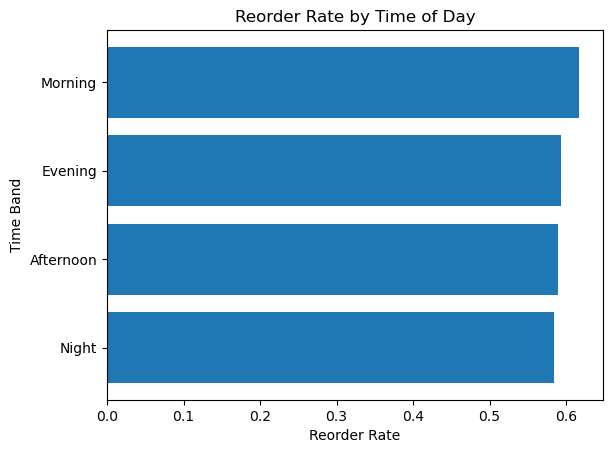

In [133]:
# Task4
reorder_time = df_instacart.groupby('order_time_band')['reordered'].mean().sort_values()

plt.figure()
plt.barh(reorder_time.index, reorder_time.values)
plt.title("Reorder Rate by Time of Day")
plt.xlabel("Reorder Rate")
plt.ylabel("Time Band")
plt.show()

In [ ]:
# Tassk 5
df_instacart['weekend_flag'] = df_instacart['order_dow'].apply(lambda x: 'weekend' if x in [0, 1] else 'weekday')
# df_instacart['weekend_flag'].value_counts()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,aisle,First Name,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division,price_range,age_group,income_group,order_time_band,expensive_product,family_size_group,senior_flag,weekend_flag
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,soft drinks,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,High-range product,Middle,Middle income,Morning,Not expensive,Large family,Not Senior,weekday
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,packaged cheese,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,High-range product,Middle,Middle income,Morning,Not expensive,Large family,Not Senior,weekday
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,yogurt,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,High-range product,Middle,Middle income,Morning,Not expensive,Large family,Not Senior,weekday
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,paper goods,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,Low-range product,Middle,Middle income,Morning,Not expensive,Large family,Not Senior,weekday
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,candy chocolate,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central,Mid-range product,Middle,Middle income,Morning,Not expensive,Large family,Not Senior,weekday
